In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

Zadanie1. Analiza czułości czasu ruiny (2pkt)

17.593 3.921906551665911


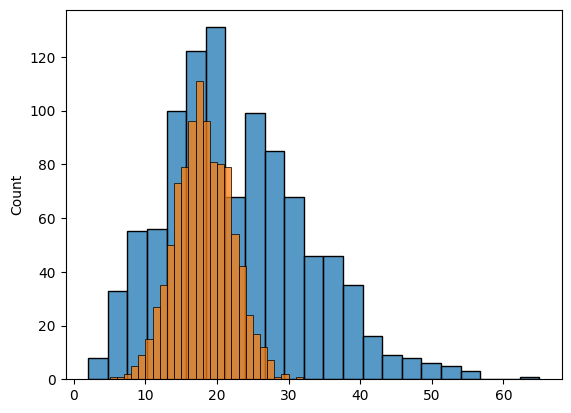

In [24]:
r0 = [10, 50, 100]
c = [1,2,3]
lam = [0.5, 1, 2]
k = [0.5, 1, 2]
def p(c, t):
    return c * t
def ruin_times(r0, c, lam, k):
    t = 1
    while True:
        N = np.random.poisson(lam * t)
        X = np.random.exponential(k ,N)
        R = r0 + p(c, t) - np.sum(X)
        if R <= 0:
            break
        t += 1
    return t
times = [ruin_times(r0[0], c[0], lam[1], k[1]) for _ in range(1000)]
sn.histplot(times)
times = [ruin_times(r0[1], c[1], lam[2], k[2]) for _ in range(1000)]
sn.histplot(times)
print(np.mean(times), np.std(times))

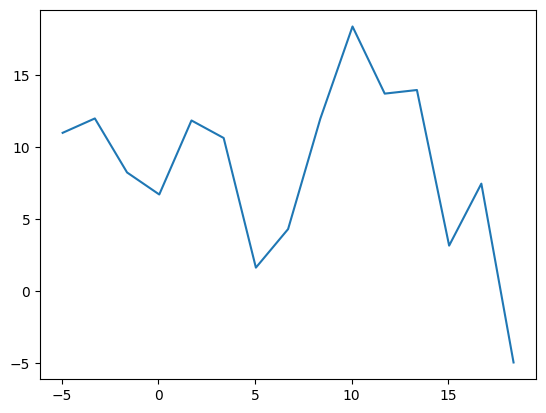

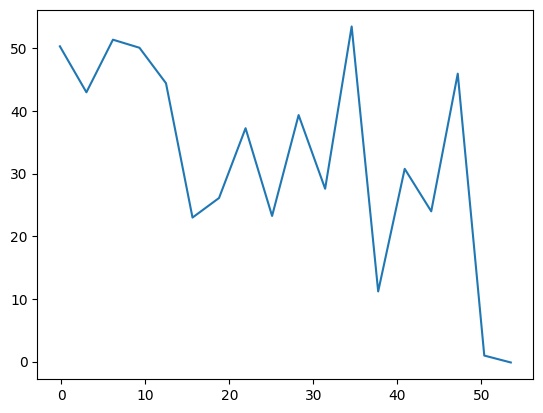

In [36]:
def ruin_times(r0, c, lam, k):
    t = 1
    R_res = []
    while True:
        N = np.random.poisson(lam * t)
        X = np.random.exponential(k ,N)
        R = r0 + p(c, t) - np.sum(X)
        R_res.append(R)
        if R <= 0:
            break
        t += 1
    return t, R_res

times = ruin_times(r0[0], c[0], lam[1], k[1])[1]
plt.plot(np.linspace(min(times), max(times), len(times)), times)
plt.show()
times = ruin_times(r0[1], c[1], lam[2], k[2])[1]
plt.plot(np.linspace(min(times), max(times), len(times)), times)
plt.show()

Zadanie 2. Ruina paryska (3 pkt)

In [37]:
def timed_ruin(r0, c, lam, k, T):
    t = 1
    under_times = []
    T_timer = 0
    while True:
        N = np.random.poisson(lam * t)
        X = np.random.exponential(k ,N)
        R = r0 + p(c, t) - np.sum(X)

        if R <= 0:
            T_timer += 1
            under_times.append(t)
        if T_timer != 0 and R>0:
            T_timer = 0
        if T_timer == T:
            break
        t += 1
    return t, under_times

t, times = timed_ruin(r0[1], c[1], lam[2], k[2], 4)
print(t, times)

30 [18, 20, 22, 23, 24, 27, 28, 29, 30]


Zadanie 3. Eksperymenty z ruiną paryską (2 pkt)

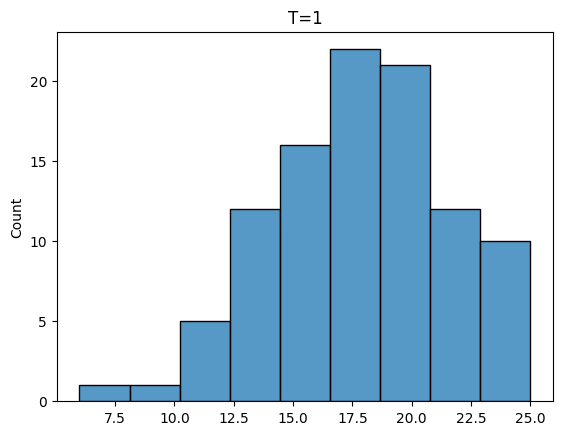

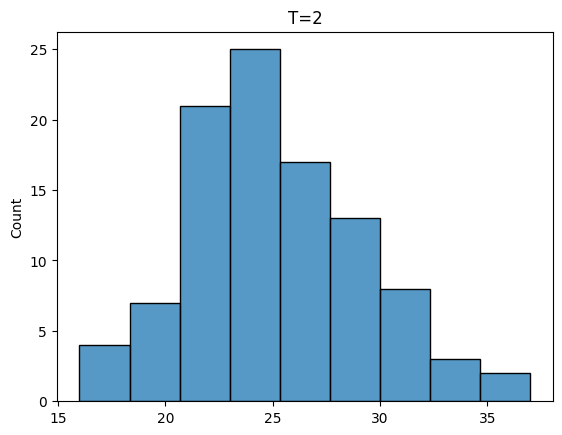

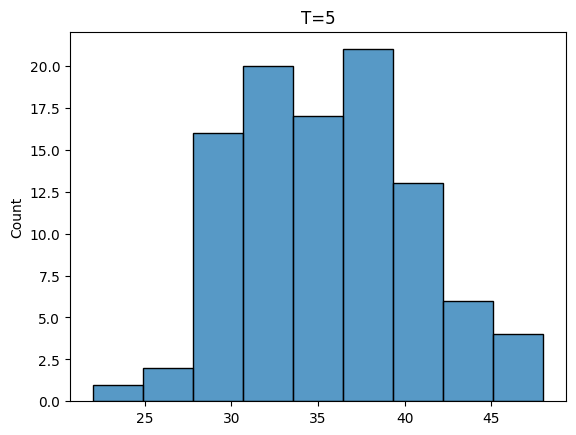

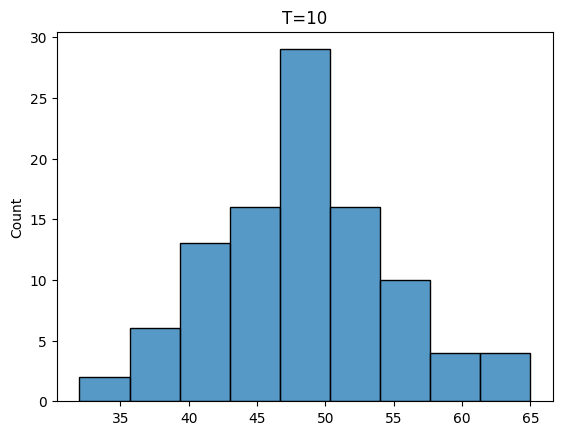

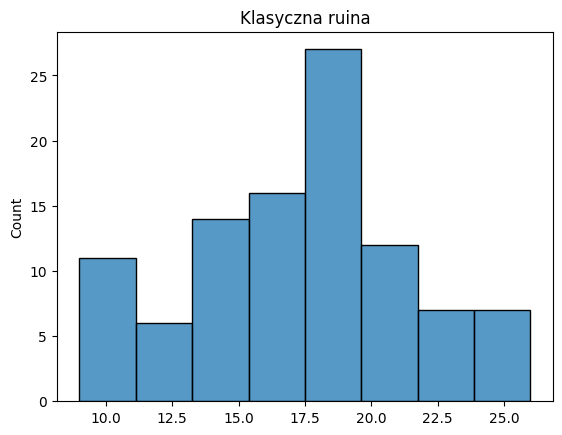

In [ ]:
T = [1,2,5,10]

times1 = [timed_ruin(r0[1], c[1], lam[2], k[2], T[0])[0] for _ in range(100)]
times2 = [timed_ruin(r0[1], c[1], lam[2], k[2], T[1])[0] for _ in range(100)]
times3 = [timed_ruin(r0[1], c[1], lam[2], k[2], T[2])[0] for _ in range(100)]
times4 = [timed_ruin(r0[1], c[1], lam[2], k[2], T[3])[0] for _ in range(100)]
times_og = [ruin_times(r0[1], c[1], lam[2], k[2])[0] for _ in range(100)]
sn.histplot(times1)
plt.title('T=1')
plt.show()
sn.histplot(times2)
plt.title('T=2')
plt.show()
sn.histplot(times3)
plt.title('T=5')
plt.show()
sn.histplot(times4)
plt.title('T=10')
plt.show()
sn.histplot(times_og)
plt.title('Klasyczna ruina')
plt.show()

#wniosek - model paryski opóźnia bankructwo

Zadanie 4. Zaawansowany model z reasekuracją i podatkami (opcjonalne)

In [ ]:
#lol oczywiście że nie zrobiłem

Zadanie 5. Symulacja mieszanego procesu Poissona (3 pkt)

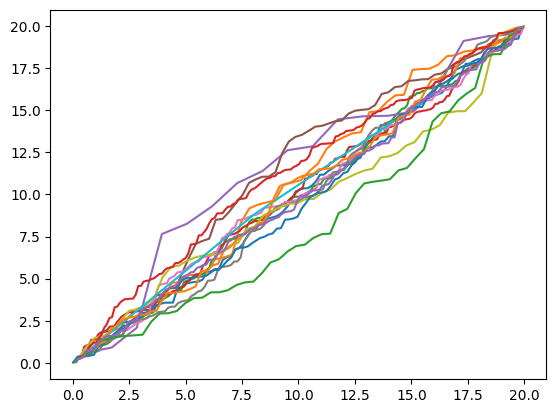

In [41]:
def wariantB(T):
    lam = np.random.uniform(0, 10)
    n = np.random.poisson(lam * T)
    U = np.random.uniform(0, T, n)
    U.sort()
    return U

trajektorie = [wariantB(20) for _ in range(15)]
for trajektoria in trajektorie:
    plt.plot(np.linspace(min(trajektoria), max(trajektoria), len(trajektoria)), trajektoria)
plt.show()

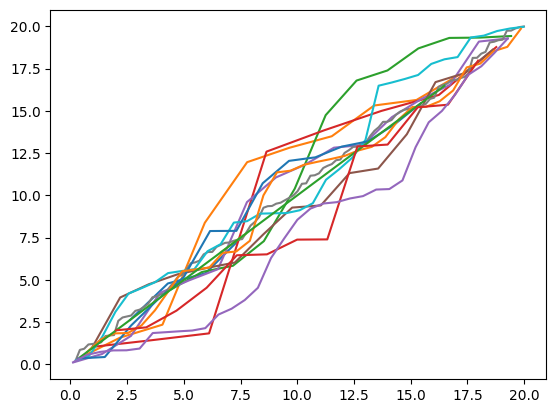

In [42]:
def wariantB(T):
    lam = np.random.exponential(1)
    n = np.random.poisson(lam * T)
    U = np.random.uniform(0, T, n)
    U.sort()
    return U

trajektorie = [wariantB(20) for _ in range(15)]
for trajektoria in trajektorie:
    plt.plot(np.linspace(min(trajektoria), max(trajektoria), len(trajektoria)), trajektoria)
plt.show()

Zadanie 6. Histogramy liczby zdarzeń (3 pkt)

In [ ]:
trajektorie1 = [wariantB(20) for _ in range(200)]
trajektorie1 = [wariantB(10) for _ in range(200)]

Zadanie 7. Symulacja ruchu Browna (3 pkt) 

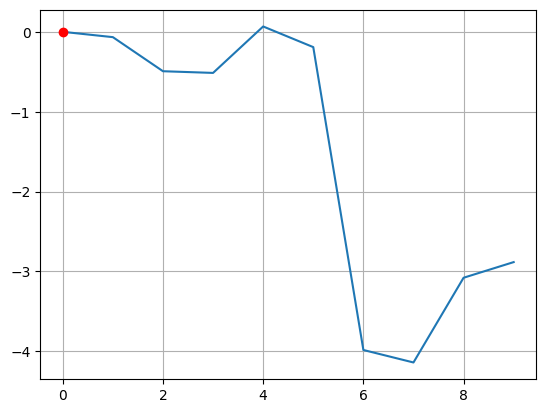

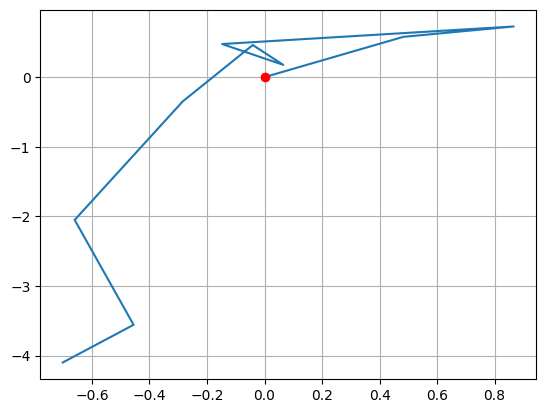

In [64]:
def Brown(T, N):
    times = np.random.uniform(0, T, N)
    times.sort()
    B = [0]
    for i in range(len(times)-1):
        Z = np.random.normal(0, 1)
        B.append(B[-1] + np.sqrt(times[i+1] - times[i]) * Z)
    return B

trajektoria = Brown(10, 10)
plt.plot(range(len(trajektoria)), trajektoria)
plt.grid(True)
plt.plot([0], [0], 'ro')
plt.show()
trajektoria1, trajektoria2 = Brown(10, 10), Brown(10, 10)
plt.plot(trajektoria1, trajektoria2)
plt.grid(True)
plt.plot([0], [0], 'ro')
plt.show()

Zadanie 8. Wariancja ruchu Browna (2 pkt)

Zadanie 9. Procesy Levy'ego (4 pkt)

Zadanie 10. Geometryczny ruch Browna (3 pkt)

In [63]:
S0 = 10
miu = 1
sigma = 1
T = 100
N = 1000
M = 5

In [ ]:
steps = np.linspace(0, T, N)
for m in range(M):
    for i in range(N):
        B = Brown()

Zadanie 11. Szacowanie parametrów i symulacja ścieżek GBM dla danych giełdowych (3 pkt)

In [2]:
import yfinance as yf

In [6]:
ticker_symbol = 'AAPL'
ticker = yf.Ticker(ticker_symbol)
historical_data = ticker.history(period="1mo")
print(historical_data)

                                 Open        High         Low       Close  \
Date                                                                        
2025-05-12 00:00:00-04:00  210.970001  211.270004  206.750000  210.789993   
2025-05-13 00:00:00-04:00  210.429993  213.399994  209.000000  212.929993   
2025-05-14 00:00:00-04:00  212.429993  213.940002  210.580002  212.330002   
2025-05-15 00:00:00-04:00  210.949997  212.960007  209.539993  211.449997   
2025-05-16 00:00:00-04:00  212.360001  212.570007  209.770004  211.259995   
2025-05-19 00:00:00-04:00  207.910004  209.479996  204.259995  208.779999   
2025-05-20 00:00:00-04:00  207.669998  208.470001  205.029999  206.860001   
2025-05-21 00:00:00-04:00  205.169998  207.039993  200.710007  202.089996   
2025-05-22 00:00:00-04:00  200.710007  202.750000  199.699997  201.360001   
2025-05-23 00:00:00-04:00  193.669998  197.699997  193.460007  195.270004   
2025-05-27 00:00:00-04:00  198.300003  200.740005  197.429993  200.210007   

In [ ]:
rt = np.log(historical_data["Close"]/historical_data["Open"])
print(rt)
mean = np.mean(rt)
std = np.std(rt)
print(mean, std)

Date
2025-05-12 00:00:00-04:00   -0.000854
2025-05-13 00:00:00-04:00    0.011810
2025-05-14 00:00:00-04:00   -0.000471
2025-05-15 00:00:00-04:00    0.002367
2025-05-16 00:00:00-04:00   -0.005193
2025-05-19 00:00:00-04:00    0.004176
2025-05-20 00:00:00-04:00   -0.003908
2025-05-21 00:00:00-04:00   -0.015126
2025-05-22 00:00:00-04:00    0.003233
2025-05-23 00:00:00-04:00    0.008228
2025-05-27 00:00:00-04:00    0.009586
2025-05-28 00:00:00-04:00   -0.000848
2025-05-29 00:00:00-04:00   -0.017992
2025-05-30 00:00:00-04:00    0.007396
2025-06-02 00:00:00-04:00    0.007065
2025-06-03 00:00:00-04:00    0.009490
2025-06-04 00:00:00-04:00   -0.000444
2025-06-05 00:00:00-04:00   -0.014204
2025-06-06 00:00:00-04:00    0.004522
2025-06-09 00:00:00-04:00   -0.014489
dtype: float64
-0.0002826809121516634 0.008815783242718252
